Setup & Load

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

HOUSE = os.environ.get("SMART_HOME_HOUSE", "hh101")
processed_path = root / "data" / "processed" / f"{HOUSE}_features_with_models.csv"
if not processed_path.exists():
    raise FileNotFoundError(f"Modeled features not found: {processed_path}")

fig_dir = root / "outputs" / "figures" / HOUSE
table_dir = root / "outputs" / "tables" / HOUSE
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_path)
df["window_start"] = pd.to_datetime(df["window_start"])
df["hour"] = df["window_start"].dt.hour + df["window_start"].dt.minute/60
df["dow"] = df["window_start"].dt.dayofweek
print(f"Loaded {len(df)} modeled windows for {HOUSE} from {processed_path}")
df.head()

Loaded 8929 modeled windows for hh101 from C:\Users\evang\Documents\GitHub\smart-home-anomaly-detection\data\processed\hh101_features_with_models.csv


,window_start,Bathroom,Bedroom,DiningRoom,Kitchen,LivingRoom,OutsideDoor,total_events,n_sensors_active,tod_sin,tod_cos,dow,is_inactive,cluster,is_anomaly,anomaly_score,hour
0,2012-07-18 12:00:00,2.0,7.0,2.0,9.0,7.0,3.0,30.0,6.0,1.224647e-16,-1.000000,2,0,5,False,0.119899,12.0
1,2012-07-18 13:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.588190e-01,-0.965926,2,1,3,False,0.113420,13.0
2,2012-07-18 14:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.000000e-01,-0.866025,2,1,3,False,0.114724,14.0
3,2012-07-18 15:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-7.071068e-01,-0.707107,2,1,3,False,0.123909,15.0
4,2012-07-18 16:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-8.660254e-01,-0.500000,2,1,3,False,0.120451,16.0


What sensors exist as features?

In [2]:
ignore_cols = {"window_start","cluster","is_anomaly","anomaly_score","hour","dow"}
non_sensor_cols = {"total_events","n_sensors_active","tod_sin","tod_cos","is_inactive"}
sensor_cols = [c for c in df.columns if c not in ignore_cols and c not in non_sensor_cols]
len(sensor_cols), sensor_cols[:10]

(6,
 ['Bathroom', 'Bedroom', 'DiningRoom', 'Kitchen', 'LivingRoom', 'OutsideDoor'])

Cluster size and time-of-day profile

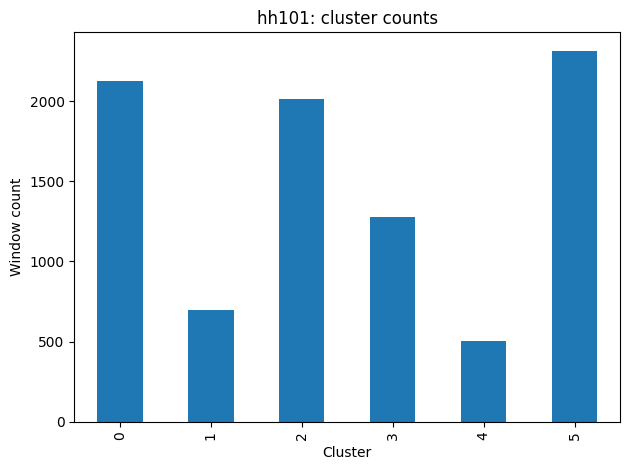

cluster
0    2123
1     698
2    2016
3    1275
4     504
5    2313
Name: count, dtype: int64

In [3]:
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_counts.to_csv(table_dir / f"{HOUSE}_cluster_counts.csv", header=["window_count"])

plt.figure()
cluster_counts.plot(kind="bar")
plt.title(f"{HOUSE}: cluster counts")
plt.xlabel("Cluster")
plt.ylabel("Window count")
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_cluster_counts.png", bbox_inches="tight")
plt.show()

cluster_counts

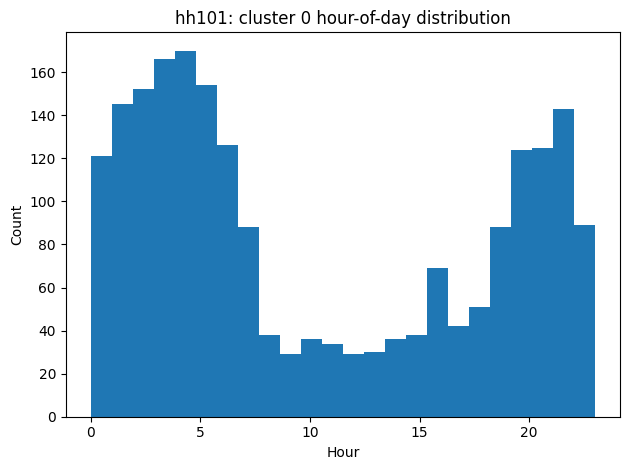

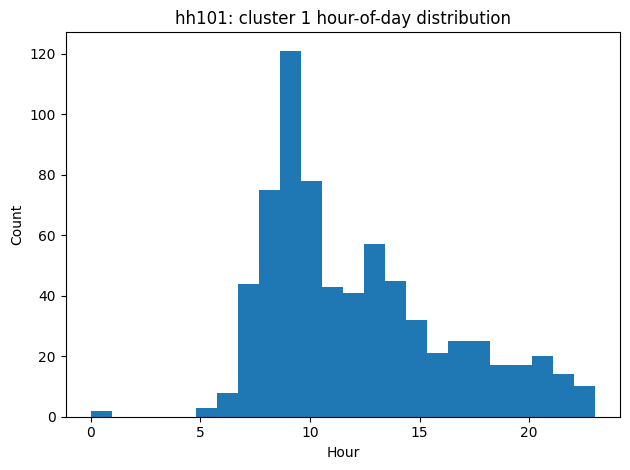

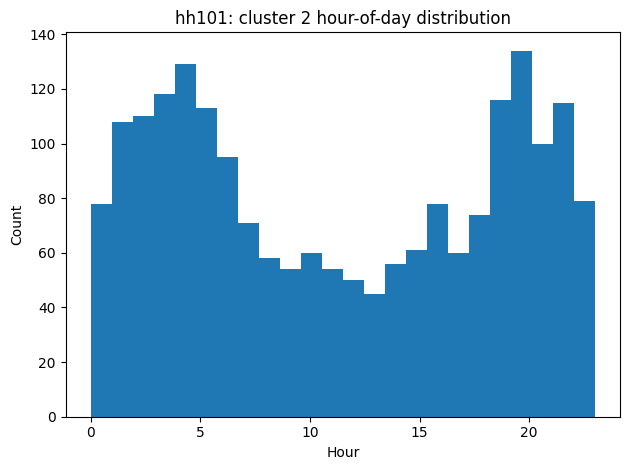

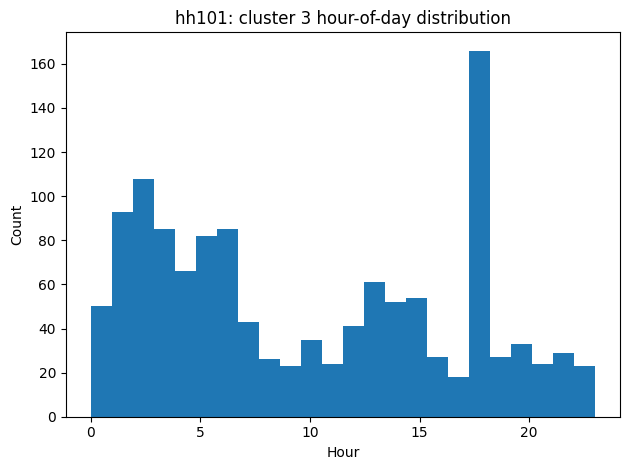

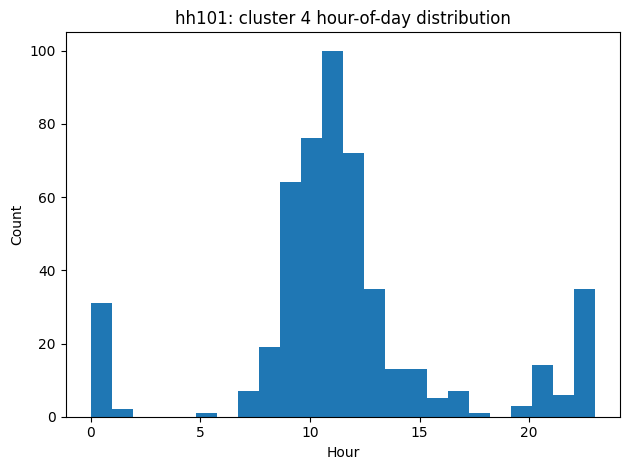

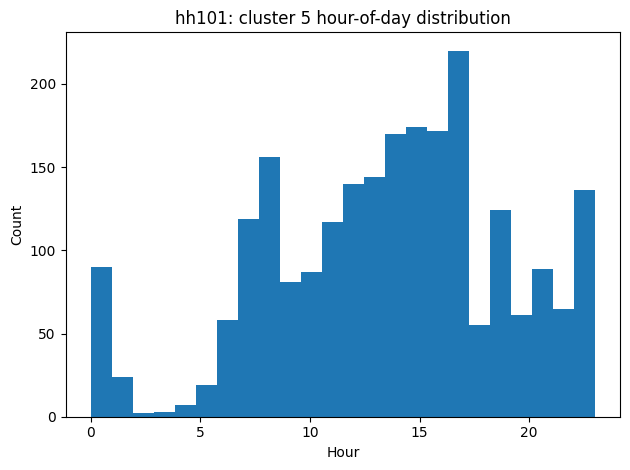

In [4]:
# Time-of-day distribution per cluster
for k in sorted(df["cluster"].unique()):
    hours = df.loc[df["cluster"]==k, "hour"].values
    plt.figure()
    plt.hist(hours, bins=24)
    plt.title(f"{HOUSE}: cluster {k} hour-of-day distribution")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{HOUSE}_cluster_{k}_hour_distribution.png", bbox_inches="tight")
    plt.show()

Top sensors per cluster

In [5]:
def top_sensors_for_cluster(k, topn=10):
    sub = df[df["cluster"]==k]
    active_sub = sub[sub["total_events"] > 0] if "total_events" in sub.columns else sub
    ref = active_sub if not active_sub.empty else sub
    means = ref[sensor_cols].mean().sort_values(ascending=False)
    if active_sub.empty or means.empty or float(means.max()) <= 0:
        return pd.Series([0.0], index=["No active sensor"])
    return means.head(topn)

for k in sorted(df["cluster"].unique()):
    print(f"\n=== Cluster {k} top sensors ===")
    print(top_sensors_for_cluster(k, topn=12))


=== Cluster 0 top sensors ===
LivingRoom     20.440886
Bedroom        11.216675
Bathroom        4.394253
Kitchen         3.901083
OutsideDoor     0.812058
DiningRoom      0.263307
dtype: float64

=== Cluster 1 top sensors ===
Kitchen        232.722063
LivingRoom     103.636103
Bathroom        25.103152
DiningRoom      16.759312
Bedroom         12.729226
OutsideDoor      5.706304
dtype: float64

=== Cluster 2 top sensors ===
LivingRoom     29.208333
Bedroom         9.280258
Kitchen         4.567460
Bathroom        4.188492
OutsideDoor     1.126488
DiningRoom      0.369544
dtype: float64

=== Cluster 3 top sensors ===
No active sensor    0.0
dtype: float64

=== Cluster 4 top sensors ===
Bedroom        264.289683
Bathroom       211.113095
LivingRoom      82.817460
Kitchen         40.166667
OutsideDoor      8.773810
DiningRoom       5.363095
dtype: float64

=== Cluster 5 top sensors ===
LivingRoom     89.474708
Bedroom        46.490705
Kitchen        35.599222
Bathroom       34.508431
Out

Cluster summary table

In [6]:
summary_rows = []
for k in sorted(df["cluster"].unique()):
    sub = df[df["cluster"]==k]
    top_sensors = top_sensors_for_cluster(k, topn=2)
    row = {
        "cluster": k,
        "n_windows": len(sub),
        "mean_total_events": sub["total_events"].mean(),
        "mean_unique_sensors": sub["n_sensors_active"].mean(),
        "inactive_fraction": (sub["total_events"] == 0).mean(),
        "peak_hour": sub["hour"].round().mode().iloc[0] if len(sub) else np.nan,
        "top_sensor_1": top_sensors.index[0] if len(top_sensors) > 0 else "",
        "top_sensor_2": top_sensors.index[1] if len(top_sensors) > 1 and top_sensors.index[0] != "No active sensor" else "",
    }
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).sort_values("cluster")
summary.to_csv(table_dir / f"{HOUSE}_cluster_summary.csv", index=False)
summary

,cluster,n_windows,mean_total_events,mean_unique_sensors,inactive_fraction,peak_hour,top_sensor_1,top_sensor_2
0,0,2123,41.028262,1.484220,0.0,4.0,LivingRoom,Bedroom
1,1,698,396.656160,4.501433,0.0,9.0,Kitchen,LivingRoom
2,2,2016,48.740575,1.589286,0.0,20.0,LivingRoom,Bedroom
3,3,1275,0.000000,0.000000,1.0,18.0,No active sensor,
4,4,504,612.523810,5.138889,0.0,11.0,Bedroom,Bathroom
5,5,2313,222.784695,4.822741,0.0,17.0,LivingRoom,Bedroom


Cluster-by-sensor comparison and clustering quality

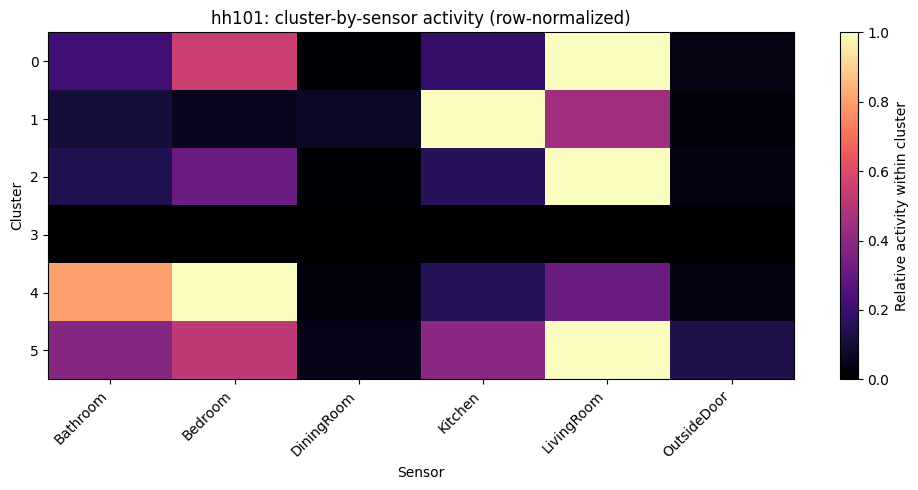

Silhouette score: 0.1960 (computed on full dataset)


,Bathroom,Bedroom,DiningRoom,Kitchen,LivingRoom,OutsideDoor
cluster,,,,,,
0,0.215,0.549,0.013,0.191,1.000,0.040
1,0.108,0.055,0.072,1.000,0.445,0.025
2,0.143,0.318,0.013,0.156,1.000,0.039
3,0.000,0.000,0.000,0.000,0.000,0.000
4,0.799,1.000,0.020,0.152,0.313,0.033
5,0.386,0.520,0.047,0.398,1.000,0.140


In [7]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

cluster_sensor = []
for k in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == k]
    active_sub = sub[sub["total_events"] > 0] if "total_events" in sub.columns else sub
    ref = active_sub if not active_sub.empty else sub
    means = ref[sensor_cols].mean()
    cluster_sensor.append(pd.Series(means, name=k))

cluster_sensor = pd.DataFrame(cluster_sensor).fillna(0.0)
cluster_sensor.index.name = "cluster"
cluster_sensor = cluster_sensor.sort_index()
cluster_sensor.to_csv(table_dir / f"{HOUSE}_cluster_sensor_matrix.csv")

cluster_sensor_normalized = cluster_sensor.div(cluster_sensor.max(axis=1).replace(0, 1), axis=0)
cluster_sensor_normalized.to_csv(table_dir / f"{HOUSE}_cluster_sensor_matrix_normalized.csv")

plt.figure(figsize=(10, 5))
plt.imshow(cluster_sensor_normalized.values, aspect="auto", cmap="magma", vmin=0, vmax=1)
plt.title(f"{HOUSE}: cluster-by-sensor activity (row-normalized)")
plt.xlabel("Sensor")
plt.ylabel("Cluster")
plt.xticks(range(len(cluster_sensor_normalized.columns)), cluster_sensor_normalized.columns, rotation=45, ha="right")
plt.yticks(range(len(cluster_sensor_normalized.index)), cluster_sensor_normalized.index)
plt.colorbar(label="Relative activity within cluster")
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_cluster_sensor_heatmap.png", bbox_inches="tight")
plt.show()

feature_cols = [
    c for c in df.columns
    if c not in {"window_start", "cluster", "is_anomaly", "anomaly_score", "hour"}
]
Xs = StandardScaler().fit_transform(df[feature_cols])
if len(df) > 10000:
    silhouette_sample = df.sample(n=10000, random_state=42)
    Xs_sample = StandardScaler().fit_transform(silhouette_sample[feature_cols])
    sil_value = silhouette_score(Xs_sample, silhouette_sample["cluster"])
    sil_note = "sampled on 10,000 windows"
else:
    sil_value = silhouette_score(Xs, df["cluster"])
    sil_note = "computed on full dataset"

silhouette_summary = pd.DataFrame(
    [{"silhouette_score": sil_value, "note": sil_note, "n_clusters": df["cluster"].nunique()}]
)
silhouette_summary.to_csv(table_dir / f"{HOUSE}_silhouette_score.csv", index=False)

print(f"Silhouette score: {sil_value:.4f} ({sil_note})")
cluster_sensor_normalized.round(3)

Assign semi-automatic routine labels

In [8]:
from IPython.display import display

# Build labels from the cluster summary instead of hardcoding cluster IDs.
def time_bucket(hour):
    if pd.isna(hour):
        return "Unknown"
    if 0 <= hour < 6:
        return "Night"
    if 6 <= hour < 11:
        return "Morning"
    if 11 <= hour < 17:
        return "Midday"
    if 17 <= hour < 22:
        return "Evening"
    return "Late-night"

def build_cluster_label(row):
    period = time_bucket(row["peak_hour"])
    top_sensor_1 = str(row["top_sensor_1"]).strip()
    top_sensor_2 = str(row["top_sensor_2"]).strip()

    if row["inactive_fraction"] >= 0.95 or top_sensor_1 == "No active sensor":
        return f"{period} inactivity"

    if row["mean_unique_sensors"] >= 4:
        return f"{period} multi-room routine"

    if top_sensor_2:
        return f"{period} {top_sensor_1} + {top_sensor_2} routine"
    if top_sensor_1:
        return f"{period} {top_sensor_1} routine"
    return f"{period} routine"

cluster_labels = summary.copy()
cluster_labels["routine_label"] = cluster_labels.apply(build_cluster_label, axis=1)
cluster_name = dict(zip(cluster_labels["cluster"], cluster_labels["routine_label"]))
cluster_labels[["cluster", "routine_label", "inactive_fraction", "peak_hour", "top_sensor_1", "top_sensor_2"]].to_csv(
    table_dir / f"{HOUSE}_cluster_labels.csv", index=False
)

df["routine_label"] = df["cluster"].map(cluster_name).fillna("Unlabeled routine")

display(cluster_labels[["cluster", "routine_label", "inactive_fraction", "peak_hour", "top_sensor_1", "top_sensor_2"]])
df[["window_start", "cluster", "routine_label", "total_events", "n_sensors_active"]].head(20)

,cluster,routine_label,inactive_fraction,peak_hour,top_sensor_1,top_sensor_2
0,0,Night LivingRoom + Bedroom routine,0.0,4.0,LivingRoom,Bedroom
1,1,Morning multi-room routine,0.0,9.0,Kitchen,LivingRoom
2,2,Evening LivingRoom + Bedroom routine,0.0,20.0,LivingRoom,Bedroom
3,3,Evening inactivity,1.0,18.0,No active sensor,
4,4,Midday multi-room routine,0.0,11.0,Bedroom,Bathroom
5,5,Evening multi-room routine,0.0,17.0,LivingRoom,Bedroom


,window_start,cluster,routine_label,total_events,n_sensors_active
0,2012-07-18 12:00:00,5,Evening multi-room routine,30.0,6.0
1,2012-07-18 13:00:00,3,Evening inactivity,0.0,0.0
2,2012-07-18 14:00:00,3,Evening inactivity,0.0,0.0
3,2012-07-18 15:00:00,3,Evening inactivity,0.0,0.0
4,2012-07-18 16:00:00,3,Evening inactivity,0.0,0.0
5,2012-07-18 17:00:00,3,Evening inactivity,0.0,0.0
6,2012-07-18 18:00:00,3,Evening inactivity,0.0,0.0
7,2012-07-18 19:00:00,3,Evening inactivity,0.0,0.0
8,2012-07-18 20:00:00,3,Evening inactivity,0.0,0.0
9,2012-07-18 21:00:00,3,Evening inactivity,0.0,0.0
